In [ ]:
!pip install --upgrade langchain langchain-community langgraph  openai langchain_openai -q

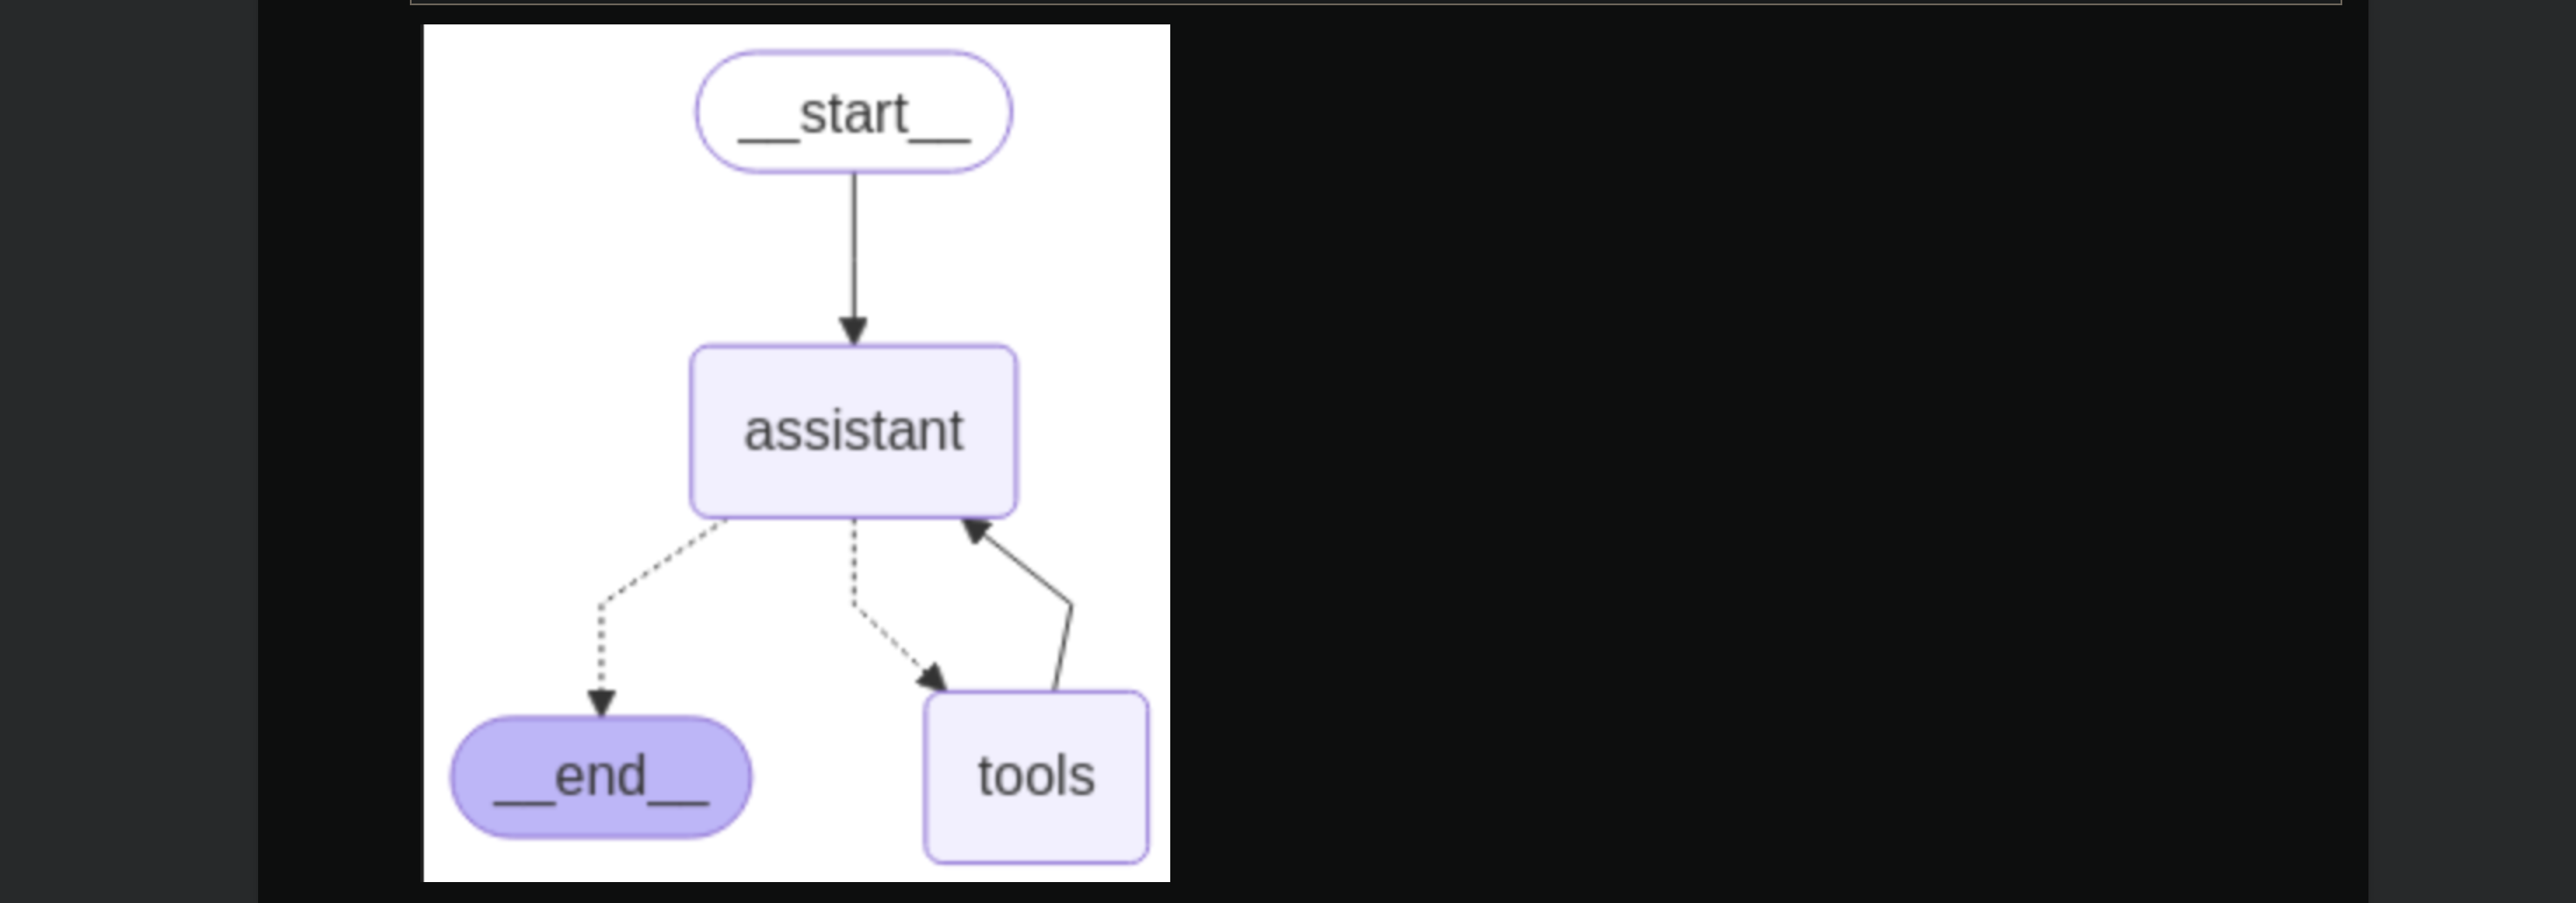

### Problem Statement

Design a **LangGraph-based agent workflow** that allows an AI assistant to decide whether it should directly answer a user’s query or use external tools to gather additional information.

The workflow begins at the **`__start__`** node, where the user query enters the system. The request is then passed to the **assistant node**, which represents the main LLM responsible for understanding the query and deciding the next action. The assistant evaluates the query and determines whether it has enough knowledge to respond directly or whether it needs to invoke external tools such as APIs, databases, or retrieval systems.

If the assistant decides that a tool is required, the workflow moves to the **tools node**, where the appropriate tool is executed. The output from the tool is then returned back to the **assistant node** so that the assistant can use the retrieved information to continue reasoning or generate a final response.

If the assistant determines that it already has sufficient information, it sends the response directly to the **`__end__`** node, completing the workflow. This architecture allows the assistant to **iteratively call tools and refine responses before producing the final output**, enabling more accurate and context-aware answers.

The goal of this workflow is to build a **tool-aware AI agent** that can intelligently combine reasoning with external information sources to answer user queries effectively.


In [ ]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START
from langchain_openai import ChatOpenAI
import requests
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState

from langgraph.prebuilt import ToolNode, tools_condition

from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

/Users/ingledarshan/.local/share/virtualenvs/AH-KbrtVpZi/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# class State(TypedDict): # TypedDict is a way to define a dictionary with specific keys and value types. In this case, State is a dictionary that has a key 'messages' which is a list of messages. The add_messages function is used to specify that the 'messages' key should be treated as a list of messages in the context of the graph.
#     messages: Annotated[list, add_messages] # eg: [SystemMessage(content="You are a helpful assistant."), HumanMessage(content="What is the capital of France?")]

class State(TypedDict):
    messages: Annotated[list, add_messages]

In [5]:
!pip install -U duckduckgo-search -q


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [6]:
from langchain_community.tools import DuckDuckGoSearchRun
search = DuckDuckGoSearchRun()
search.invoke("Obama's first name?")

" As you might imagine, for Barack, running for president is nothing compared to that first game of basketball with my brother, Craig. I can't tell you how much it means to have Craig and my mom here … 贝拉克·侯赛因·奥巴马（Barack Hussein Obama），1961年8月4日出生于美国夏威夷州檀香山，美国民主党籍政治家，第44任美国总统，美国历史上第一位非洲裔总统。 1991年，奥巴马以优等生荣誉从 … 美国第44任总统奥巴马的全称是 巴拉克·侯赛因·奥巴马 二世（Barack Hussein Obama II）。称其为二世，是为了与和他姓名完全相同的父亲（巴拉克·侯赛因·奥巴马一世）相区别。在西方许多国家，父子 … 上涨自然会导致更多人宁愿被罚款 0 元都不买保险，于是又导致保费继续上涨。 Trump 确实因为缺乏一个能够团结一致废除 Obamacare 的两院。 （Obama 推动两院通过 Obamacare 也确实很不容易。 …"

In [7]:
from langchain_community.tools import DuckDuckGoSearchRun

def search_duckduckgo(query: str):
    """Searches DuckDuckGo using LangChain's DuckDuckGoSearchRun tool."""
    search = DuckDuckGoSearchRun()
    return search.invoke(query)

# Example usage
result = search_duckduckgo("what are AI agent")
print(result)

Want to see Maya Murad explain more about AI Agents ? The difference between AI and AI Agents . Why Traditional AI Is Limited. Today's mainstream AIs—like ChatGPT, Gemini, Claude, etc.— are extremely powerful when it comes to generating text, analyzing data, answering questions, or transforming information. Think of AI agents as smart assistants that can take actions. For example, if you ask a chatbot, “Can you book a flight for me?”, a basic AI model might say, “Sure, here are some sites where you can book it.”This is what we call Agentic AI — AI with agency (power to act). What are agents ? " Agent " can be defined in several ways.Appendix 1: Agents in practice. Our work with customers has revealed two particularly promising applications for AI agents that demonstrate the practical value of the patterns discussed above. Start Building an AI Agent for Free. AI agent frameworks are changing how teams build software. They let you focus on outcomes instead of infrastructure, and Botpress

In [9]:
def multiply(a:int,b:int) -> int:
    """
    Multiply a and b
    """
    return a* b

def add(a:int,b:int) -> int:
    """
    Adds a and b
    """
    return a + b

In [10]:
from langchain_openai import ChatOpenAI
import os
llm = ChatOpenAI(temperature=0, api_key=os.environ["OPENAI_API_KEY"], model="gpt-4o-mini")


In [11]:
llm.invoke('hello').content

'Hello! How can I assist you today?'

In [12]:
tools = [search_duckduckgo, add, multiply]

llm_with_tools = llm.bind_tools(tools)

In [13]:
def chatbot(state: State):
    return {"messages": [llm_with_tools.invoke(state["messages"])]}



In [14]:
from langgraph.prebuilt import ToolNode, tools_condition

graph_builder = StateGraph(State)

# Define nodes
graph_builder.add_node("assistant",chatbot)
graph_builder.add_node("tools",ToolNode(tools))

#define edges
graph_builder.add_edge(START,"assistant")
graph_builder.add_conditional_edges("assistant",tools_condition)
graph_builder.add_edge("tools","assistant")

react_graph=graph_builder.compile()

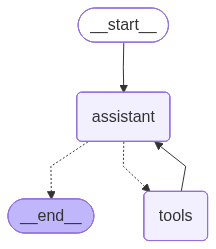

In [15]:
# To see the graph’s connection visually

display(Image(react_graph.get_graph().draw_mermaid_png()))

In [16]:
response = react_graph.invoke({"messages": [HumanMessage(content="what is the weather in delhi. Multiply it by 2 and add 5.")]})
print(response["messages"])

[HumanMessage(content='what is the weather in delhi. Multiply it by 2 and add 5.', additional_kwargs={}, response_metadata={}, id='6b431bd8-9642-4ad2-a00c-857e932d862f'), AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 117, 'total_tokens': 137, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_cdd011970c', 'id': 'chatcmpl-DOmFC1QqkhqBsPXut7nY4Yyo5Y1XM', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019d3a2f-9bc0-7341-8789-86927383fe8e-0', tool_calls=[{'name': 'search_duckduckgo', 'args': {'query': 'current weather in Delhi'}, 'id': 'call_gAjzid2iounPewnjiIh9qHQk', 'type': 'tool_call'}], invalid_tool_calls=[], us

In [17]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is the weather in delhi. Multiply it by 2 and add 5.
================================== Ai Message ==================================
Tool Calls:
  search_duckduckgo (call_gAjzid2iounPewnjiIh9qHQk)
 Call ID: call_gAjzid2iounPewnjiIh9qHQk
  Args:
    query: current weather in Delhi
================================= Tool Message =================================
Name: search_duckduckgo

Weather forecast for Delhi for today, tomorrow, and the coming days. Current regional conditions. New Delhi /Safdarjung Airport (216m). New Delhi - Weather warnings issued. 14-day forecast. Current local time in India – Delhi – New Delhi . Get New Delhi 's weather and area codes, time zone and DST. Get the World weather forecast. Access hourly, 10 day and 15 day forecasts along with up to the minute reports and videos from AccuWeather.com. Weather in the world today Accurate weather forecast Detailed forecast Today & To

# Happy Learning